---
# 1.  LLM Nedir?

**LLM (Large Language Model - Büyük Dil Modeli)**, devasa miktarda metin verisi üzerinde eğitilmiş yapay zeka modelleridir.

### Basit Tanım
Bir LLM'i şöyle düşünebilirsiniz: **İnternetin büyük bir bölümünü okumuş ve bu metinlerdeki kalıpları (pattern) öğrenmiş bir sistem.** Bu sayede:

-  Metin yazabilir
-  Soruları cevaplayabilir
-  Çeviri yapabilir
-  Kod yazabilir
-  Özetleme yapabilir
-  Yaratıcı içerik üretebilir

### Neden "Büyük"?
"Büyük" kelimesi iki anlama gelir:
1. **Eğitim verisi büyüklüğü**: Milyarlarca kelimelik metin verisi
2. **Model parametresi sayısı**: Milyarlarca hatta trilyonlarca parametre


### LLM Nasıl Çalışır?

LLM'ler temelde **bir sonraki kelimeyi tahmin etme** prensibiyle çalışır:

```
Girdi: "Türkiye'nin başkenti"
Model düşünür: "Ankara" kelimesinin gelme olasılığı en yüksek → %95
Çıktı: "Ankara"
```

Bu basit prensip, milyarlarca parametre ve devasa veri ile birleşince son derece güçlü bir sistem ortaya çıkar.

# LLM Architecture
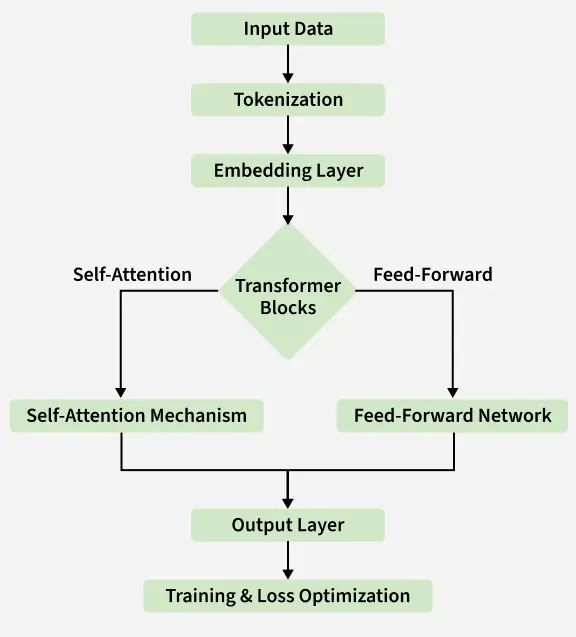

**Input Data**
Modele verilen ham veridir; genellikle metindir. Örneğin “Ali okula gitti” cümlesi modelin giriş verisidir.

**Tokenization**
Metin daha küçük parçalara bölünür. “Ali okula gitti” ifadesi “Ali | okula | gitti” şeklinde token’lara ayrılır ve her biri bir ID alır.

**Embedding Layer**
Her token sayısal bir vektöre dönüştürülür. Örneğin “Ali” kelimesi model içinde [0.12, -0.8, 1.03, …] gibi bir vektörle temsil edilir; böylece kelimeler matematiksel olarak işlenebilir hale gelir.

**Transformer Blocks**
Modelin asıl “zeka” kısmıdır; burada embedding’ler işlenir ve anlam çıkarılır. Bu bloklar iki ana yapıdan oluşur: self-attention ve feed-forward.

**Self-Attention Mechanism**
Kelimelerin birbirleriyle ilişkisine bakılır. Örneğin “Ali topu Ayşe’ye attı” cümlesinde model, “attı” fiilinin “Ali” ile ve “top” ile bağlantılı olduğunu öğrenir; yani hangi kelimenin hangisiyle ilgili olduğunu kavrar.

**Feed-Forward Network**
Self-attention’dan çıkan bilgiyi daha derinlemesine işler ve dönüştürür. Örneğin “Ali” kelimesinin gerçekten bir kişi olduğunu ve özne rolünde bulunduğunu daha net hale getirir.

**Output Layer**
Modelin son karar verdiği katmandır. Burada bir sonraki kelimenin olasılıkları hesaplanır. Örneğin “Bugün hava…” girdisinden sonra “güzel” kelimesinin seçilmesi bu katmanda olur.

**Training & Loss Optimization**
Modelin hata yapıp yapmadığı ölçülür ve kendini düzeltmesi sağlanır. Örneğin doğru cevap “güzel” iken model “soğuk” dediyse, hata hesaplanır ve model ağırlıkları güncellenir.

---
# 3.  LLM'ler Nasıl Kullanılır?

LLM'leri kullanmanın temel yolları:

| Yöntem | Açıklama | Örnek |
|--------|----------|-------|
| **Web Arayüzü** | Tarayıcı üzerinden doğrudan kullanım | ChatGPT, Gemini, Claude |
| **API** | Programatik erişim (kod ile) | OpenAI API, Gemini API |
| **Kütüphaneler** | Python SDK'ları | google-generativeai, openai |
| **Yerel Çalıştırma** | Kendi bilgisayarınızda | Ollama, LM Studio |



In [ ]:
# Gemini Python SDK kurulumu
!pip install -q -U google-genai

In [ ]:
import google.genai as genai
from google.colab import userdata



GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
print(" API anahtarı Colab Secrets'tan alındı.")


# API'yi yapılandır
genai.configure(api_key=GEMINI_API_KEY)
print(" Gemini API yapılandırıldı!")

 API anahtarı Colab Secrets'tan alındı.
 Gemini API yapılandırıldı!


In [ ]:
# Gemini modelini oluştur
model = genai.GenerativeModel("gemini-2.0-flash")

# İlk sorumuzu soralım
yanit = model.generate_content("Yapay zeka nedir? Kısaca açıkla.")

print(" Gemini'nin Yanıtı:")
print("-" * 50)
print(yanit.text)

 Gemini'nin Yanıtı:
--------------------------------------------------
Yapay zeka (YZ), genel olarak insan zekasını taklit edebilen veya gerektiren görevleri gerçekleştirebilen bilgisayar sistemleri veya makineleridir. Bu görevler arasında öğrenme, problem çözme, karar verme ve algılama yer alır.

**Özetle:** Bilgisayarların düşünme ve öğrenme yeteneği.



---
# 4.  LLM Seçimi

Piyasada birçok LLM bulunuyor. Doğru modeli seçmek, projenizin başarısı için kritik öneme sahiptir.

## Seçim Kriterleri

| Kriter | Açıklama | Örnek |
|--------|----------|-------|
| **Performans** | Modelin doğruluk ve kalitesi | Benchmark skorları |
| **Hız (Latency)** | Yanıt süresi | Gerçek zamanlı chat vs. toplu işlem |
| **Maliyet** | API kullanım ücreti | Token başına fiyat |
| **Bağlam Penceresi** | Tek seferde işleyebileceği metin | 8K, 128K, 1M token |
| **Dil Desteği** | Türkçe gibi dillerdeki performans | Çok dilli modeller |
| **Gizlilik** | Verilerinizin güvenliği | Açık kaynak vs. API |
| **Özelleştirme** | Fine-tuning imkanı | Kendi verinizle eğitim |

## Kullanım Senaryosuna Göre Model Seçimi

| Senaryo | Önerilen Yaklaşım | Neden? |
|---------|-------------------|--------|
| Basit chatbot | Gemini Flash, GPT | Hızlı, ucuz |
| Karmaşık analiz | GPT, Gemini Pro, Claude Sonnet | Yüksek akıl yürütme |
| Kod yazma | Claude Sonnet, GPT-4o | Kod kalitesi yüksek |
| Uzun doküman işleme | Gemini 1.5 Pro (1M token) | Geniş bağlam penceresi |
| Gizlilik önemli | Llama, Mistral (yerel) | Veri sizde kalır |
| Düşük bütçe | Gemini Flash, açık kaynak modeller | Maliyet etkin |

In [ ]:
# Gemini'de kullanılabilir modelleri listeleyelim
print(" Kullanılabilir Gemini Modelleri:")
print("=" * 60)

for m in genai.list_models():
    if 'generateContent' in m.supported_generation_methods:
        print(f"\n Model: {m.name}")
        print(f"   Görünen Ad: {m.display_name}")
        print(f"   Girdi Token Limiti: {m.input_token_limit:,}")
        print(f"   Çıktı Token Limiti: {m.output_token_limit:,}")

 Kullanılabilir Gemini Modelleri:

 Model: models/gemini-2.5-flash
   Görünen Ad: Gemini 2.5 Flash
   Girdi Token Limiti: 1,048,576
   Çıktı Token Limiti: 65,536

 Model: models/gemini-2.5-pro
   Görünen Ad: Gemini 2.5 Pro
   Girdi Token Limiti: 1,048,576
   Çıktı Token Limiti: 65,536

 Model: models/gemini-2.0-flash
   Görünen Ad: Gemini 2.0 Flash
   Girdi Token Limiti: 1,048,576
   Çıktı Token Limiti: 8,192

 Model: models/gemini-2.0-flash-001
   Görünen Ad: Gemini 2.0 Flash 001
   Girdi Token Limiti: 1,048,576
   Çıktı Token Limiti: 8,192

 Model: models/gemini-2.0-flash-exp-image-generation
   Görünen Ad: Gemini 2.0 Flash (Image Generation) Experimental
   Girdi Token Limiti: 1,048,576
   Çıktı Token Limiti: 8,192

 Model: models/gemini-2.0-flash-lite-001
   Görünen Ad: Gemini 2.0 Flash-Lite 001
   Girdi Token Limiti: 1,048,576
   Çıktı Token Limiti: 8,192

 Model: models/gemini-2.0-flash-lite
   Görünen Ad: Gemini 2.0 Flash-Lite
   Girdi Token Limiti: 1,048,576
   Çıktı Token Limi

---
# 5.  LLM Parametreleri

LLM'lerin çıktısını kontrol etmek için kullanabileceğimiz önemli parametreler vardır. Bu parametreler, modelin yaratıcılığını, tutarlılığını ve çıktı uzunluğunu doğrudan etkiler.

## Temel Parametreler

###  Temperature (Sıcaklık)
Modelin yanıtlarındaki **rastgelelik/yaratıcılık** seviyesini kontrol eder.

| Değer | Davranış | Kullanım Alanı |
|-------|----------|----------------|
| 0.0 | Deterministik, her seferinde aynı yanıt | Doğru/yanlış cevaplar, veri çıkarma |
| 0.3-0.5 | Düşük yaratıcılık, tutarlı | İş yazışmaları, özetleme |
| 0.7-0.9 | Orta yaratıcılık | Genel sohbet |
| 1.0-2.0 | Yüksek yaratıcılık, sürpriz yanıtlar | Yaratıcı yazım, beyin fırtınası |


##  Top-P (Nucleus Sampling)

**Mantık:** Modelin aday kelimelerini olasılık sırasına koy. Olasılıkları topla. Toplam P değerine ulaşana kadar olan kelimeleri havuza al.

**Örnek:** `"Bugün hava çok ___"` cümlesini tamamlarken model şu adayları üretsin:

| Aday Kelime | Olasılık | Kümülatif Toplam |
|---|---|---|
| güzel | %40 | %40 |
| sıcak | %25 | %65 |
| soğuk | %15 | %80 |
| güneşli | %10 | %90 |
| berbat | %5 | %95 |
| kaotik | %5 | %100 |

**Top-P = 0.65** ise → Kümülatif toplam %65'e ulaşana kadar olan kelimeler havuza girer → **"güzel" ve "sıcak"** → Model bu ikisinden birini seçer.

**Top-P = 0.9** ise → Kümülatif toplam %90'a ulaşana kadar → **"güzel, sıcak, soğuk, güneşli"** → Dört kelimeden biri seçilir. Daha yaratıcı ve çeşitli çıktılar gelir.

>  **Kısacası:** Top-P küçükse model hep bilinen güvenli kelimeleri seçer. Top-P büyükse daha sürprizli, yaratıcı kelimeler de devreye girer.

---

##  Top-K

**Mantık:** Olasılıklara bakmadan, **sadece en yüksek olasılıklı K tane kelimeyi** havuza al.

Aynı örnek üzerinden:

- **Top-K = 1** → Sadece "güzel" → Her seferinde aynı cevabı verir
- **Top-K = 3** → "güzel, sıcak, soğuk" → Bu üçünden birini seçer
- **Top-K = 40** → En olası 40 kelime havuza girer → Çok çeşitli

>  **Top-K ile Top-P farkı:** Top-K her zaman sabit sayıda kelime alır (mesela hep 40 tane). Top-P ise **olasılık dağılımına göre dinamik** çalışır. Model bir kelimeden çok eminse (%95 "güzel" diyorsa), Top-P havuzu otomatik daraltır. Top-K daraltamaz, yine 40 kelime alır.

---

##  Max Output Tokens

**Mantık:** Modelin üretebileceği **maksimum uzunluk sınırı.** Bu limite ulaşınca cevap bitmese bile durur.

**Örnek:** "Bana Türkiye'nin tarihini anlat" dediğinizde:

- **Max Tokens = 50** → 1-2 cümle yazar, keser
- **Max Tokens = 500** → Birkaç paragraf yazar
- **Max Tokens = 4096** → Uzun bir makale yazar

>  **Dikkat:** 1 token ≠ 1 kelime. Türkçede **1 kelime yaklaşık 1.5-2 token** eder. Yani max_tokens=100 dediğinizde yaklaşık 50-65 kelime alırsınız.

---

## 4.  Stop Sequences

**Mantık:** Modele **"bu yazıyı gördüğünde dur"** deme yöntemidir. Belirlediğiniz karakter dizisini gördüğü anda üretimi keser.

**Örnek:** Diyelim bir chatbot yapıyorsunuz. Model hem asistan hem kullanıcı rolünde yazmaya devam edebilir:

> **Stop Sequence yoksa:**
>
> Asistan: Merhaba, nasıl yardımcı olabilirim?
> Kullanıcı: Hava nasıl? *(bunu model uydurdu!)*
> Asistan: Bugün güneşli... *(kendi kendine konuşuyor)*

> **Stop Sequence = "Kullanıcı:" ise:**
>
> Asistan: Merhaba, nasıl yardımcı olabilirim? ← **DURDU.** Çünkü sıradaki "Kullanıcı:" yazısını gördü.

>  **Kısacası:** Stop sequence olmadan model, token limiti dolana kadar yazmaya devam eder ve bazen kendi kendine soru sorup cevaplama gibi istenmeyen şeyler yapabilir.

---

##  Özet Karşılaştırma

| Parametre | Ne Yapar | Düşük Değer → | Yüksek Değer → |
|---|---|---|---|
| **Top-P** | Olasılık havuzunun genişliğini belirler | Güvenli, tahmin edilebilir | Yaratıcı, çeşitli |
| **Top-K** | Sabit sayıda aday kelime belirler | Tekrarlı, deterministik | Çeşitli, sürprizli |
| **Max Tokens** | Çıktı uzunluk sınırı koyar | Kısa yanıtlar | Uzun yanıtlar |
| **Stop Sequences** | Belirli bir yazıda durmasını sağlar | — | — |


In [ ]:
# Temperature etkisini görelim

print(" TEMPERATURE ETKİSİ")
print("=" * 60)

soru = "Bir startup için yaratıcı bir isim öner ve nedenini açıkla. Konu: yapay zeka destekli yemek tarifi uygulaması."

temperature_degerleri = [0.0, 0.5, 1.0, 1.5]

for temp in temperature_degerleri:
    model = genai.GenerativeModel(
        "gemini-2.0-flash",
        generation_config=genai.GenerationConfig(temperature=temp)
    )

    yanit = model.generate_content(soru)

    print(f"\n Temperature = {temp}")
    print("-" * 40)
    print(yanit.text[:300])
    print()

 TEMPERATURE ETKİSİ

 Temperature = 0.0
----------------------------------------
## Startup İsmi Önerisi: **"Lezzet Algoritması"**

**Neden Bu İsim?**

Bu isim, startup'ın temel işlevini ve değerini net bir şekilde ifade ediyor ve aynı zamanda akılda kalıcı ve yaratıcı bir etki yaratıyor:

*   **"Lezzet":** Uygulamanın yemek ve tat odaklı olduğunu vurguluyor. İnsanların en temel


 Temperature = 0.5
----------------------------------------
## Startup İsmi Önerisi: **"Lezzet Algoritması"**

**Neden Bu İsim?**

Bu isim, startup'ın temel işlevini ve değerini net bir şekilde ifade ediyor:

*   **"Lezzet":** Yemek ve tat alma duyusuna doğrudan gönderme yaparak, uygulamanın odak noktasının yemek olduğunu vurguluyor. Kullanıcıların ilgisini 


 Temperature = 1.0
----------------------------------------
Elbette, işte yapay zeka destekli yemek tarifi uygulaması için yaratıcı bir isim ve açıklaması:

**İsim: LezzetHarita (Lezzet Haritası)**

**Neden?**

*   **Çağrışım:** "Lezzet" kelimesi doğrud

In [ ]:
# Max tokens etkisi

print(" MAX TOKENS ETKİSİ")
print("=" * 60)

soru = "Python programlama dilinin tarihçesini anlat."

token_limitleri = [50, 150, 500]

for limit in token_limitleri:
    model = genai.GenerativeModel(
        "gemini-2.0-flash",
        generation_config=genai.GenerationConfig(
            max_output_tokens=limit,
            temperature=0.3
        )
    )

    yanit = model.generate_content(soru)

    print(f"\n Max Tokens = {limit}")
    print("-" * 40)
    print(yanit.text)
    print()

 MAX TOKENS ETKİSİ

 Max Tokens = 50
----------------------------------------
Python, 1980'lerin sonlarında Guido van Rossum tarafından Hollanda'da geliştirilmeye başlanmış ve ilk sürümü 1991'de yayınlanmıştır. Python'ın tarihçesi ve gelişim


 Max Tokens = 150
----------------------------------------
Python programlama dilinin tarihçesi oldukça ilginç ve gelişim dolu bir süreçtir. İşte Python'ın tarihçesinin ana hatları:

**1. Doğuş ve İlk Yıllar (1980'lerin Sonu - 1990'ların Başı):**

*   **Guido van Rossum:** Python'ın yaratıcısı, Hollandalı bilgisayar bilimcisi Guido van Rossum'dur.
*   **ABC Dili Etkisi:** Van Rossum, daha önce CWI (Centrum Wiskunde & Informatica) adlı araştırma enstitüsünde ABC programlama dili üzerinde çalışmıştı. ABC, öğrenmesi kolay ve kullanımı basit bir dil olmayı hedef


 Max Tokens = 500
----------------------------------------
Python programlama dilinin tarihçesi oldukça ilginç ve gelişim dolu bir süreçtir. İşte Python'ın tarihçesinin ana hatları:

**1. D

---
# 6. 🌐 LLM Örnekleri - Piyasadaki Modeller

## Kapalı Kaynak (Proprietary) Modeller

| Model | Geliştirici | Öne Çıkan Özellik |
|-------|------------|--------------------|
| **GPT-4o** | OpenAI | Çok modlu (metin, görüntü, ses), güçlü akıl yürütme |
| **Gemini** | Google | 1M+ token bağlam, çok modlu, Google entegrasyonu |
| **Claude** | Anthropic | Uzun bağlam, güvenlik odaklı, kod yazma |
| **Grok** | xAI | X (Twitter) verisiyle güncellenen, gerçek zamanlı bilgi |

## Açık Kaynak (Open Source) Modeller

| Model | Geliştirici | Öne Çıkan Özellik |
|-------|------------|--------------------|
| **Llama 3.1** | Meta | 8B/70B/405B boyut, ticari kullanım serbest |
| **Mistral** | Mistral AI | Küçük boyut, yüksek performans |
| **Gemma** | Google | Hafif, araştırma dostu |
| **Qwen 2.5** | Alibaba | Çok dilli, güçlü performans |
| **DeepSeek** | DeepSeek | Matematik ve kodlamada güçlü |

## Kapalı vs Açık Kaynak Karşılaştırma

| Özellik | Kapalı Kaynak | Açık Kaynak |
|---------|---------------|-------------|
| Performans | Genellikle daha yüksek | Hızla yaklaşıyor |
| Maliyet | API ücreti | Ücretsiz (donanım maliyeti) |
| Gizlilik | Veri sağlayıcıya gider | Veri sizde kalır |
| Özelleştirme | Sınırlı | Tam kontrol |
| Kurulum | Kolay (API) | Teknik bilgi gerekli |

---
# 7.  Proje: Kişisel Yemek Asistanı

Şimdi öğrendiğimiz her şeyi bir araya getirerek bir **Kişisel Yemek Asistanı** yapacağız!

Bu projede:
- Gemini API kullanımı
- System prompt ile modele rol verme
- Parametre ayarlama
- Çok turlu sohbet (multi-turn conversation)
- Kullanıcıdan bilgi alma

konularını pratiğe dökeceğiz.

In [ ]:
# ============================================
#  KİŞİSEL YEMEK ASİSTANI
# ============================================

# System prompt ile modele rol veriyoruz
SISTEM_PROMPTU = """
Sen "AşçıBot" adında samimi ve bilgili bir Türk mutfağı uzmanısın.

Görevlerin:
- Kullanıcının elindeki malzemelere göre yemek tarifi öner
- Tarifleri adım adım açıkla
- Besin değerleri hakkında bilgi ver
- Mutfak ipuçları paylaş

Kuralların:
- Her zaman Türkçe yanıt ver
- Samimi ve sıcak bir dil kullan
- Tarifleri adım adım ve anlaşılır şekilde açıkla
- Porsiyon bilgisini mutlaka belirt
- Alternatif malzeme önerileri sun
"""

# Modeli yapılandır
asci_bot = genai.GenerativeModel(
    model_name="gemini-2.0-flash",
    generation_config=genai.GenerationConfig(
        temperature=0.7,        # Yaratıcı ama tutarlı
        top_p=0.85,
        max_output_tokens=1024
    ),
    system_instruction=SISTEM_PROMPTU
)

print(" AşçıBot Hazır!")
print("Yemek tarifleri, malzeme önerileri ve mutfak ipuçları için buradayım!")

In [ ]:
# Tek seferlik soru-cevap

soru = "Elimde yumurta, domates, biber ve peynir var. Ne yapabilirim?"

print(f" Kullanıcı: {soru}")
print()

yanit = asci_bot.generate_content(soru)

print(" AşçıBot:")
print(yanit.text)

In [ ]:
# Çok turlu sohbet (Multi-turn Conversation)
# Chat oturumu başlat - model önceki mesajları hatırlar

sohbet = asci_bot.start_chat(history=[])

print(" Çok Turlu Sohbet Başladı!")
print("=" * 50)

# 1. Tur
mesaj1 = "Merhaba! Bu akşam misafirlerim gelecek, 4 kişilik kolay bir ana yemek önerir misin?"
print(f"\n Kullanıcı: {mesaj1}")
yanit1 = sohbet.send_message(mesaj1)
print(f"\n AşçıBot: {yanit1.text}")

print("\n" + "-" * 50)

# 2. Tur - Model önceki mesajı hatırlıyor
mesaj2 = "Güzel fikir! Peki yanına hangi salata yakışır?"
print(f"\n Kullanıcı: {mesaj2}")
yanit2 = sohbet.send_message(mesaj2)
print(f"\n AşçıBot: {yanit2.text}")

print("\n" + "-" * 50)

# 3. Tur - Bağlamı korumaya devam
mesaj3 = "Tatlı olarak da bir önerin var mı? Misafirlerden biri glütensiz besleniyor."
print(f"\n Kullanıcı: {mesaj3}")
yanit3 = sohbet.send_message(mesaj3)
print(f"\n AşçıBot: {yanit3.text}")

In [ ]:
# Sohbet geçmişini inceleyelim

print(" Sohbet Geçmişi:")
print("=" * 50)

for i, mesaj in enumerate(sohbet.history):
    rol = " Kullanıcı" if mesaj.role == "user" else " AşçıBot"
    print(f"\n[{i+1}] {rol}:")
    print(f"    {mesaj.parts[0].text[:100]}...")

In [ ]:
# ============================================
#  İNTERAKTİF SOHBET MODU
# ============================================
# Gerçek zamanlı sohbet - 'çıkış' yazarak sonlandırabilirsiniz

print(" AşçıBot İnteraktif Mod")
print("=" * 50)
print("Yemek tarifleri hakkında sorularınızı sorun!")
print("Çıkmak için 'çıkış' yazın.")
print("=" * 50)

interaktif_sohbet = asci_bot.start_chat(history=[])

while True:
    kullanici_mesaji = input("\n Siz: ")

    if kullanici_mesaji.lower() in ['çıkış', 'cikis', 'quit', 'exit']:
        print("\n AşçıBot: Afiyet olsun! Tekrar beklerim! ")
        break

    if not kullanici_mesaji.strip():
        continue

    try:
        yanit = interaktif_sohbet.send_message(kullanici_mesaji)
        print(f"\n AşçıBot: {yanit.text}")
    except Exception as e:
        print(f"\n Hata oluştu: {e}")
        print("Tekrar deneyin.")